In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [6]:
conn = sqlite3.connect('inventory.db')

df = pd.read_sql_query("select * from vendor_sales_summary", conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,102870.0,3707966.30,521877.42,189011.43,68601.68,-103285.30,-2.785497,0.709057,0.972900
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,119415.0,3603554.81,434336.68,219413.59,144929.24,-200486.41,-5.563573,0.727972,0.947296
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,142892.0,3481318.08,359591.59,262552.03,123780.22,63014.40,1.810073,0.762469,1.018434
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,131088.0,2991076.12,324672.29,240863.56,257032.07,-270121.82,-9.030924,0.649974,0.917171
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,97298.0,3049267.02,420473.22,178774.01,257032.07,26061.01,0.854665,0.704502,1.008620


In [7]:
#summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,2.247317e+03,8120.451298,0.00,19.000000,165.000000,1352.250000,2.539500e+05
TotalSalesDollars,10692.0,3.063106e+04,122023.629003,0.00,399.787500,3545.515000,20485.402500,3.707966e+06
TotalSalesPrice,10692.0,1.387679e+04,33978.296646,0.00,132.635000,1858.010000,11475.995000,5.218774e+05


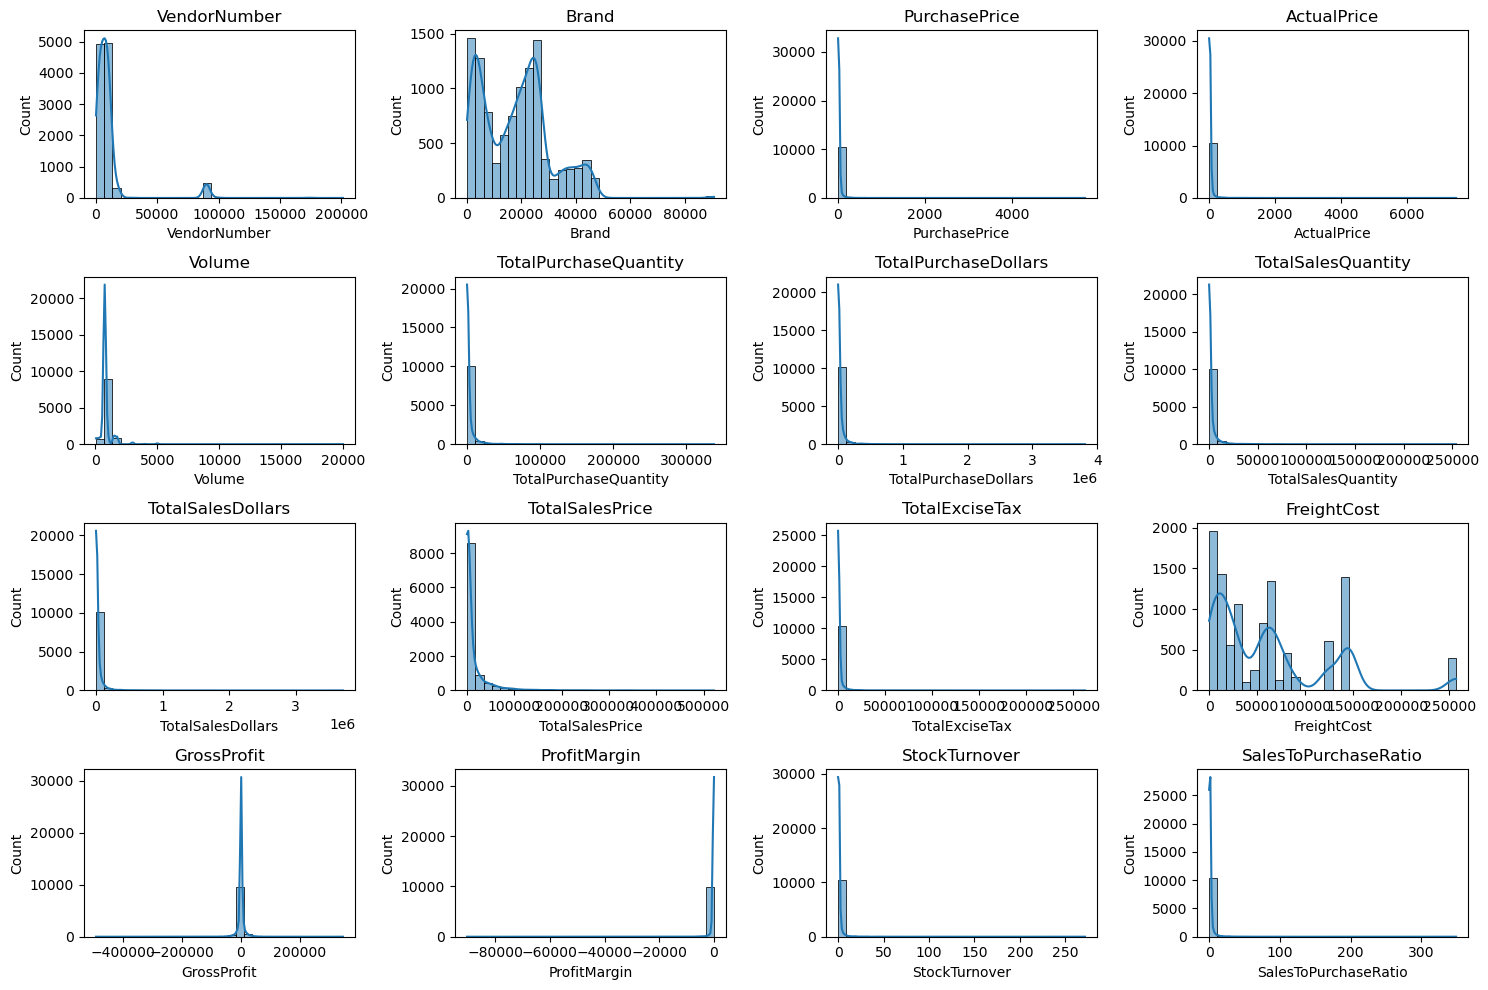

In [9]:
#Distribution plots for numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

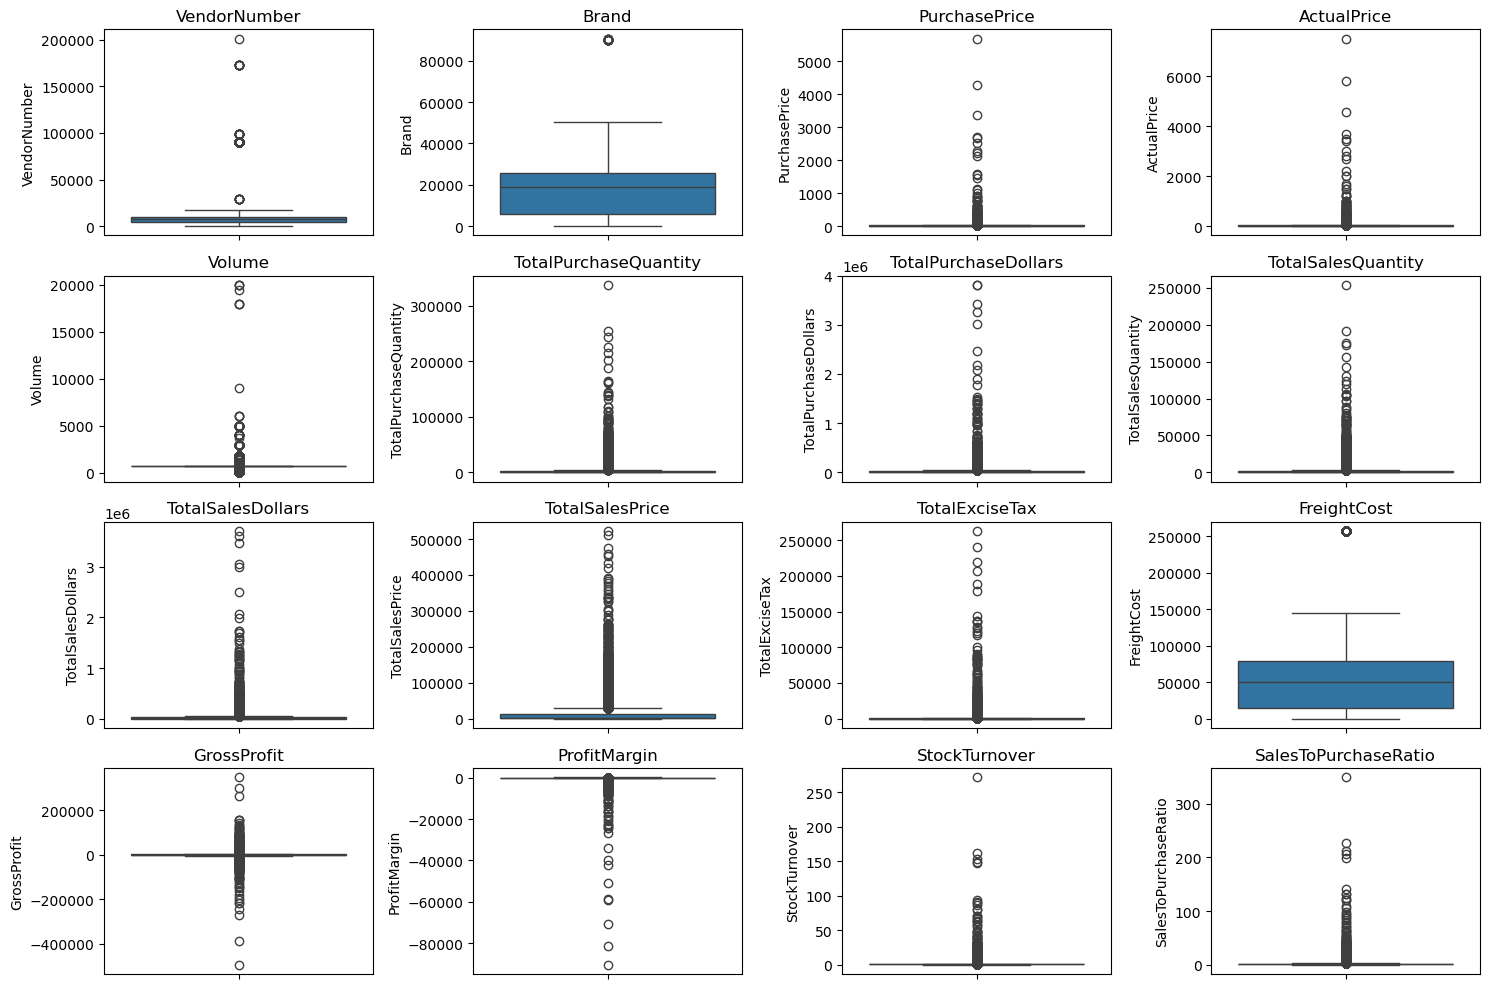

In [10]:
#outlier plots for numerical columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [11]:
#lets filter the data by removing inconsistences
df = pd.read_sql_query("""SELECT *
FROM vendor_sales_summary
WHERE GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0""",conn)

In [12]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,142892.0,3481318.08,359591.59,262552.03,123780.22,63014.40,1.810073,0.762469,1.018434
1,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,97298.0,3049267.02,420473.22,178774.01,257032.07,26061.01,0.854665,0.704502,1.008620
2,480,BACARDI USA INC,3858,Grey Goose Vodka,17.77,23.99,750.0,138809,2466635.93,104696.0,2504395.04,346117.08,82436.58,89286.27,37759.11,1.507714,0.754245,1.015308
3,3960,DIAGEO NORTH AMERICA INC,3489,Tanqueray,20.73,27.99,1750.0,91835,1903739.55,70108.0,2061442.92,392805.94,128812.43,257032.07,157703.37,7.650145,0.763413,1.082839
4,480,BACARDI USA INC,2663,Dewars White Label,21.42,29.99,1750.0,69001,1478001.42,49070.0,1558019.30,384335.05,90159.03,89286.27,80017.88,5.135872,0.711149,1.054139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6049,3960,DIAGEO NORTH AMERICA INC,2626,Crown Royal Apple,1.42,1.99,50.0,2,2.84,14.0,27.86,5.97,0.73,257032.07,25.02,89.806174,7.000000,9.809859
6050,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
6051,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
6052,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,57.0,113.43,55.72,11.97,257032.07,111.96,98.704047,57.000000,77.163265


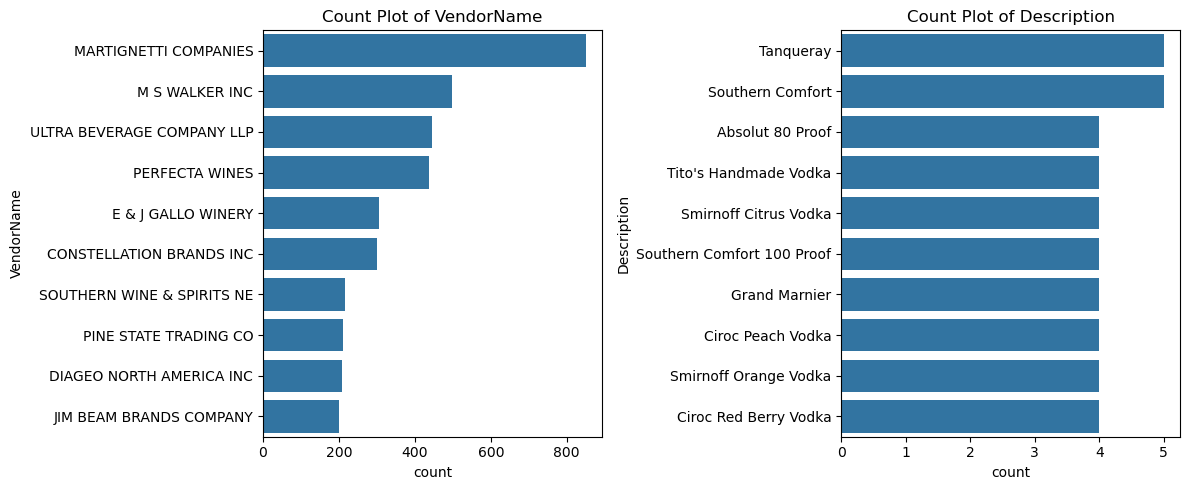

In [15]:
#count plots for categorial columns
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10])
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

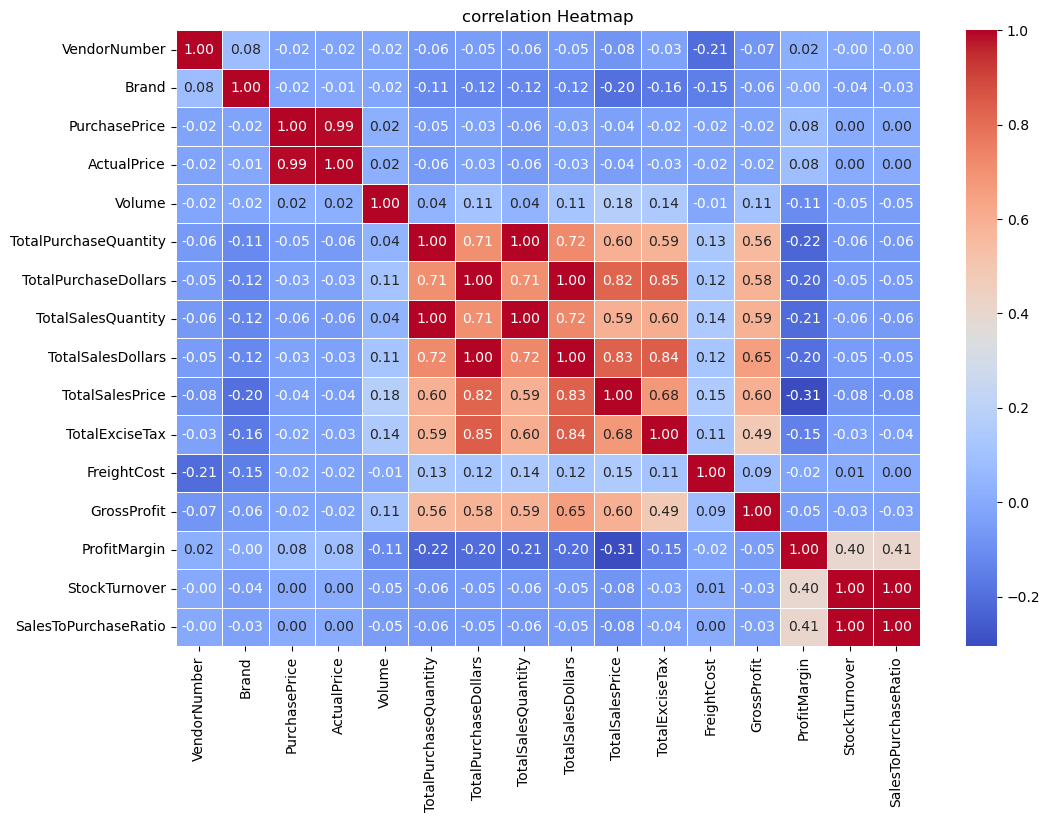

In [16]:
#correlation heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("correlation Heatmap")
plt.show()

In [23]:
#brand performance 
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'}).reset_index()
    

In [24]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [25]:
low_sales_threshold

np.float64(547.315)

In [26]:
high_margin_threshold

np.float64(72.0054628691891)

In [27]:
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]
print("Brands with low Sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))


Brands with low Sales but High Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
1626,Concannon Glen Ellen Wh Zin,15.95,83.448276
1708,Crown Royal Apple,27.86,89.806174
4534,Sauza Sprklg Wild Berry Marg,27.96,82.153076
3511,Merry Irish Cream Liqueur,35.97,73.533500
5237,Tracia Syrah,44.94,88.495772
...,...,...,...
704,Bowman's Light Vodka,535.00,72.052336
2727,Il Poggione di Montalcino,536.97,78.212936
997,Casa Liliana Good Chard,538.51,94.986166
1764,Dad's Hat Rye Whiskey,538.89,81.851584


In [42]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars']<1000]

Target Brands:
                     Description  TotalSalesDollars  GrossProfit  ProfitMargin
4     12 Days of Pearls Gift Set             309.69       302.50     97.678323
31                4 Orange Vodka             483.78       415.58     85.902683
37       A Bichot Adelie Mercury             781.77       553.67     70.822620
38  A Bichot Ch Gris Nuits St Ge             589.90       549.22     93.103916
42        A Bichot Merc Champs M             515.88       487.78     94.552997


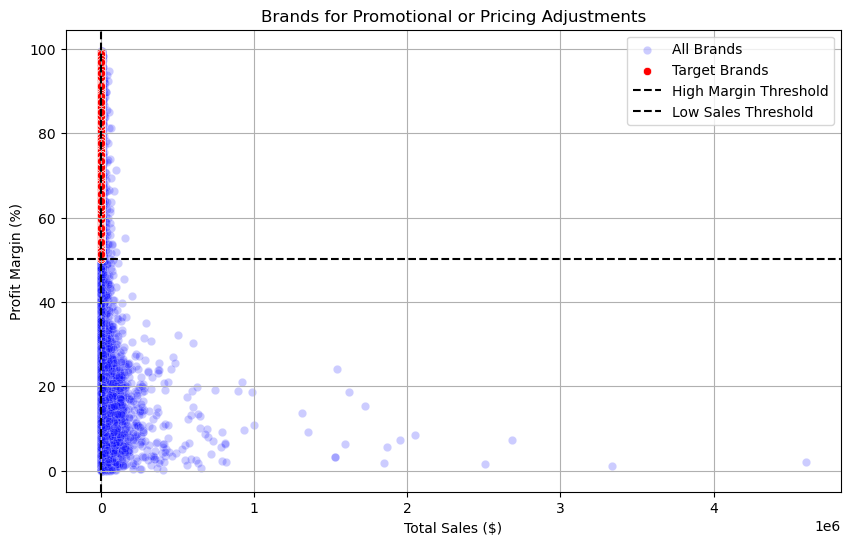

In [43]:
# Brand Performance Analysis

brand_performance = (
    df.groupby('Description')
    .agg({
        'TotalSalesDollars': 'sum',
        'GrossProfit': 'sum'
    })
    .reset_index()
)

# Calculate Profit Margin
brand_performance['ProfitMargin'] = (
    brand_performance['GrossProfit']
    / brand_performance['TotalSalesDollars']
) * 100

# Remove invalid values
brand_performance.replace([np.inf, -np.inf], np.nan, inplace=True)
brand_performance.dropna(inplace=True)

# Thresholds
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.75)
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.25)

# Brands with high margin but low sales
target_brands = brand_performance[
    (brand_performance['ProfitMargin'] > high_margin_threshold) &
    (brand_performance['TotalSalesDollars'] < low_sales_threshold)
]

print("Target Brands:")
print(target_brands.head())

# Visualization
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=brand_performance,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color='blue',
    label='All Brands',
    alpha=0.2
)

sns.scatterplot(
    data=target_brands,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color='red',
    label='Target Brands'
)

plt.axhline(
    y=high_margin_threshold,
    linestyle='--',
    color='black',
    label='High Margin Threshold'
)

plt.axvline(
    x=low_sales_threshold,
    linestyle='--',
    color='black',
    label='Low Sales Threshold'
)

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")

plt.legend()
plt.grid(True)

plt.show()

In [49]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)

In [52]:
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)

top_brands

Description
Absolut 80 Proof                4601308.23
Ketel One Vodka                 3335089.11
Tanqueray                       2681280.51
Grey Goose Vodka                2504395.04
Bombay Sapphire Gin             2049584.50
Jose Cuervo Especial            1951895.73
Dewars White Label              1867482.52
Tito's Handmade Vodka           1848175.91
Kendall Jackson Chard Vt RSV    1726337.71
Capt Morgan Original Barrel     1619199.60
Name: TotalSalesDollars, dtype: float64

In [54]:
top_brands.apply(fromat_dollars)

Description
Absolut 80 Proof                4.60M
Ketel One Vodka                 3.34M
Tanqueray                       2.68M
Grey Goose Vodka                2.50M
Bombay Sapphire Gin             2.05M
Jose Cuervo Especial            1.95M
Dewars White Label              1.87M
Tito's Handmade Vodka           1.85M
Kendall Jackson Chard Vt RSV    1.73M
Capt Morgan Original Barrel     1.62M
Name: TotalSalesDollars, dtype: object

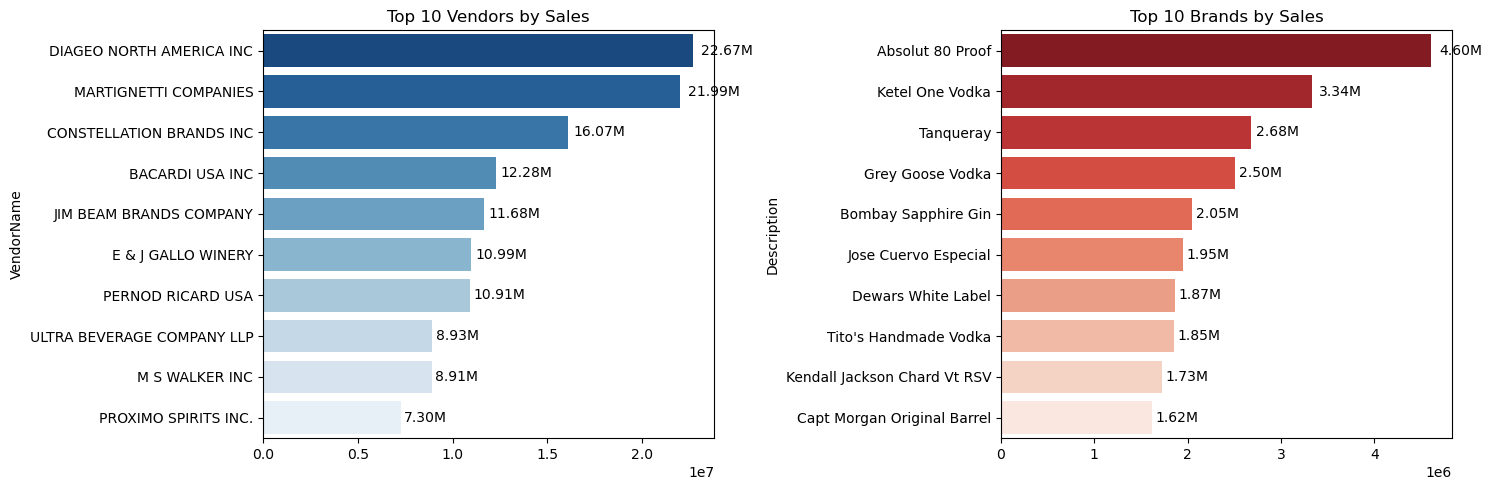

In [56]:
plt.figure(figsize=(15, 5))

# Plot for Top Vendors
plt.subplot(1, 2, 1)

ax1 = sns.barplot(
    y=top_vendors.index,
    x=top_vendors.values,
    palette="Blues_r"
)

plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

# Plot for Top Brands
plt.subplot(1, 2, 2)

ax2 = sns.barplot(
    y=top_brands.index.astype(str),
    x=top_brands.values,
    palette="Reds_r"
)

plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

plt.tight_layout()
plt.show()

In [79]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars': 'sum',
    'GrossProfit': 'sum',
    'TotalSalesDollars': 'sum'
}).reset_index()
vendor_performance.shape

(104, 4)

In [99]:
vendor_performance['PurchaseContribution%'] = (
    vendor_performance['TotalPurchaseDollars']
    / vendor_performance['TotalPurchaseDollars'].sum()
) * 100


In [100]:
vendor_performance = vendor_performance.sort_values(
    by='PurchaseContribution%',
    ascending=False
).round(2)

In [101]:
vendor_performance.head()

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
23,DIAGEO NORTH AMERICA INC,20667609.08,2006888.63,22674497.71,11.83
50,MARTIGNETTI COMPANIES,17727786.98,4261503.35,21989290.33,10.15
18,CONSTELLATION BRANDS INC,13121689.93,2952458.49,16074148.42,7.51
5,BACARDI USA INC,10818523.62,1462264.92,12280788.54,6.19
40,JIM BEAM BRANDS COMPANY,10570304.62,1104998.66,11675303.28,6.05


In [102]:
# Display Top 10 Vendors

top_vendors = vendor_performance.head(10)

top_vendors['TotalSalesDollars'] = (
    top_vendors['TotalSalesDollars'].apply(format_dollars)
)
top_vendors['TotalPurchaseDollars'] = (
    top_vendors['TotalPurchaseDollars'].apply(format_dollars)
)
top_vendors['GrossProfit'] = (
    top_vendors['GrossProfit'].apply(format_dollars)
)

top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
23,DIAGEO NORTH AMERICA INC,20.67M,2.01M,22.67M,11.83
50,MARTIGNETTI COMPANIES,17.73M,4.26M,21.99M,10.15
18,CONSTELLATION BRANDS INC,13.12M,2.95M,16.07M,7.51
5,BACARDI USA INC,10.82M,1.46M,12.28M,6.19
40,JIM BEAM BRANDS COMPANY,10.57M,1.10M,11.68M,6.05
61,PERNOD RICARD USA,10.16M,755.23K,10.91M,5.81
27,E & J GALLO WINERY,9.25M,1.74M,10.99M,5.30
47,M S WALKER INC,7.38M,1.53M,8.91M,4.23
93,ULTRA BEVERAGE COMPANY LLP,7.11M,1.82M,8.93M,4.07
66,PROXIMO SPIRITS INC.,6.35M,947.23K,7.30M,3.63


In [103]:
top_vendors['PurchaseContribution%'].sum()

np.float64(64.77)

In [104]:
top_vendors['Cumulative_Contribution%'] = (
    top_vendors['PurchaseContribution%'].cumsum()
)

top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_Contribution%
23,DIAGEO NORTH AMERICA INC,20.67M,2.01M,22.67M,11.83,11.83
50,MARTIGNETTI COMPANIES,17.73M,4.26M,21.99M,10.15,21.98
18,CONSTELLATION BRANDS INC,13.12M,2.95M,16.07M,7.51,29.49
5,BACARDI USA INC,10.82M,1.46M,12.28M,6.19,35.68
40,JIM BEAM BRANDS COMPANY,10.57M,1.10M,11.68M,6.05,41.73
61,PERNOD RICARD USA,10.16M,755.23K,10.91M,5.81,47.54
27,E & J GALLO WINERY,9.25M,1.74M,10.99M,5.30,52.84
47,M S WALKER INC,7.38M,1.53M,8.91M,4.23,57.07
93,ULTRA BEVERAGE COMPANY LLP,7.11M,1.82M,8.93M,4.07,61.14
66,PROXIMO SPIRITS INC.,6.35M,947.23K,7.30M,3.63,64.77


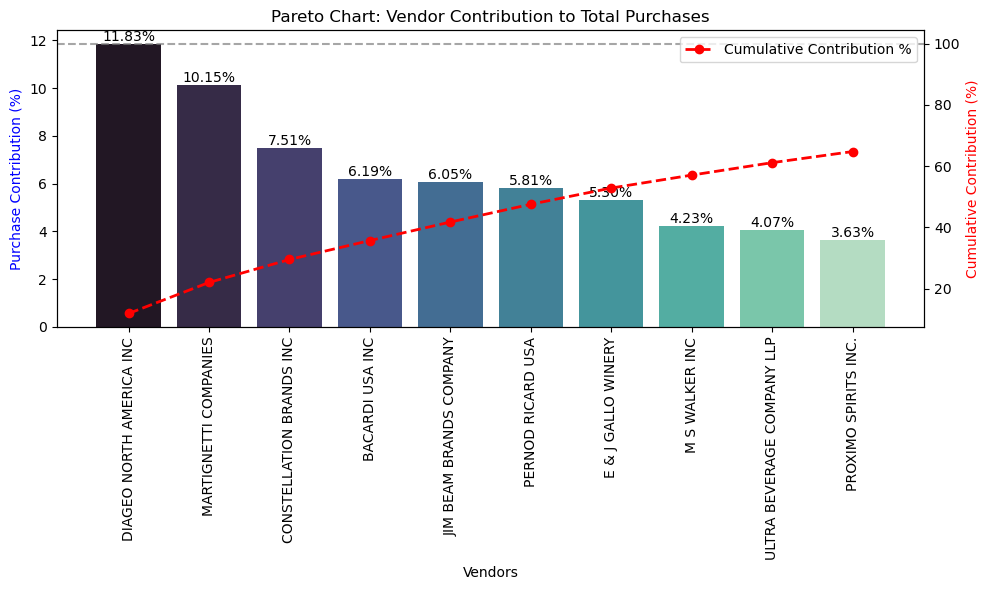

In [110]:
fig, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=top_vendors,
    x="VendorName",
    y="PurchaseContribution%",
    palette="mako",
    ax=ax1
)

# Add bar labels
for i, value in enumerate(top_vendors["PurchaseContribution%"]):
    ax1.text(
        i,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Secondary axis for cumulative line
ax2 = ax1.twinx()

ax2.plot(
    top_vendors["VendorName"],
    top_vendors["Cumulative_Contribution%"],
    color="red",
    marker="o",
    linestyle="dashed",
    linewidth=2,
    label="Cumulative Contribution %"
)

ax1.set_xlabel("Vendors")
ax1.set_ylabel("Purchase Contribution (%)", color="blue")
ax2.set_ylabel("Cumulative Contribution (%)", color="red")
ax1.set_title("Pareto Chart: Vendor Contribution to Total Purchases")

ax1.tick_params(axis="x", rotation=90)

ax2.axhline(
    y=100,
    color="gray",
    linestyle="dashed",
    alpha=0.7
)

ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [113]:
print(
    f"Total Purchase Contribution of top 10 vendors is "
    f"{round(top_vendors['PurchaseContribution%'].sum(), 2)}%"
)

Total Purchase Contribution of top 10 vendors is 64.77%


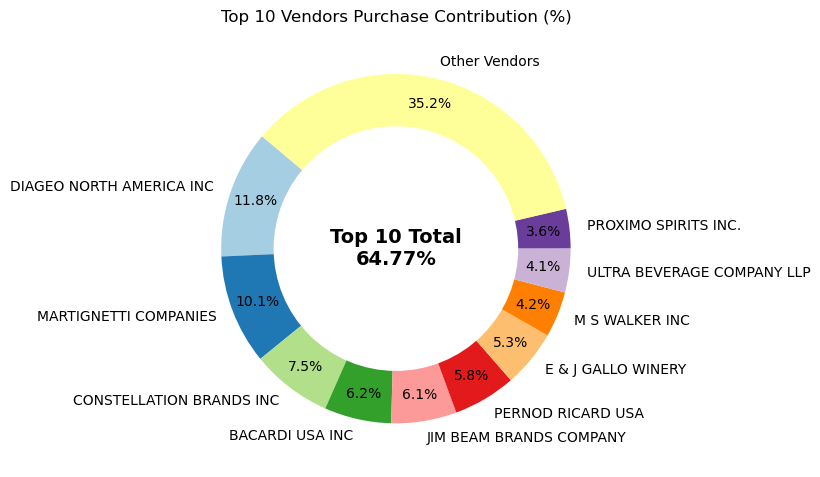

In [115]:
vendors = list(top_vendors['VendorName'])

purchase_contributions = list(
    top_vendors['PurchaseContribution%']
)

total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Add Other Vendors category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

# Create donut hole
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
ax.add_artist(centre_circle)

# Center text
ax.text(
    0,
    0,
    f"Top 10 Total\n{total_contribution:.2f}%",
    ha='center',
    va='center',
    fontsize=14,
    fontweight='bold'
)

plt.title("Top 10 Vendors Purchase Contribution (%)")
plt.tight_layout()
plt.show()

In [117]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']

In [118]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio,UnitPurchasePrice
0,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,142892.0,3481318.08,359591.59,262552.03,123780.22,63014.40,1.810073,0.762469,1.018434,18.24
1,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,97298.0,3049267.02,420473.22,178774.01,257032.07,26061.01,0.854665,0.704502,1.008620,21.89
2,480,BACARDI USA INC,3858,Grey Goose Vodka,17.77,23.99,750.0,138809,2466635.93,104696.0,2504395.04,346117.08,82436.58,89286.27,37759.11,1.507714,0.754245,1.015308,17.77
3,3960,DIAGEO NORTH AMERICA INC,3489,Tanqueray,20.73,27.99,1750.0,91835,1903739.55,70108.0,2061442.92,392805.94,128812.43,257032.07,157703.37,7.650145,0.763413,1.082839,20.73
4,480,BACARDI USA INC,2663,Dewars White Label,21.42,29.99,1750.0,69001,1478001.42,49070.0,1558019.30,384335.05,90159.03,89286.27,80017.88,5.135872,0.711149,1.054139,21.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6049,3960,DIAGEO NORTH AMERICA INC,2626,Crown Royal Apple,1.42,1.99,50.0,2,2.84,14.0,27.86,5.97,0.73,257032.07,25.02,89.806174,7.000000,9.809859,1.42
6050,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667,1.32
6051,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829,0.39
6052,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,57.0,113.43,55.72,11.97,257032.07,111.96,98.704047,57.000000,77.163265,1.47


In [119]:
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q =3, labels=["small", "Medium", "Large"])

In [120]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio,UnitPurchasePrice,OrderSize
0,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,142892.0,3481318.08,359591.59,262552.03,123780.22,63014.40,1.810073,0.762469,1.018434,18.24,Large
1,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,97298.0,3049267.02,420473.22,178774.01,257032.07,26061.01,0.854665,0.704502,1.008620,21.89,Large
2,480,BACARDI USA INC,3858,Grey Goose Vodka,17.77,23.99,750.0,138809,2466635.93,104696.0,2504395.04,346117.08,82436.58,89286.27,37759.11,1.507714,0.754245,1.015308,17.77,Large
3,3960,DIAGEO NORTH AMERICA INC,3489,Tanqueray,20.73,27.99,1750.0,91835,1903739.55,70108.0,2061442.92,392805.94,128812.43,257032.07,157703.37,7.650145,0.763413,1.082839,20.73,Large
4,480,BACARDI USA INC,2663,Dewars White Label,21.42,29.99,1750.0,69001,1478001.42,49070.0,1558019.30,384335.05,90159.03,89286.27,80017.88,5.135872,0.711149,1.054139,21.42,Large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6049,3960,DIAGEO NORTH AMERICA INC,2626,Crown Royal Apple,1.42,1.99,50.0,2,2.84,14.0,27.86,5.97,0.73,257032.07,25.02,89.806174,7.000000,9.809859,1.42,small
6050,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667,1.32,small
6051,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829,0.39,small
6052,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,57.0,113.43,55.72,11.97,257032.07,111.96,98.704047,57.000000,77.163265,1.47,small


In [122]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
small,43.709342
Medium,13.433914
Large,9.041952


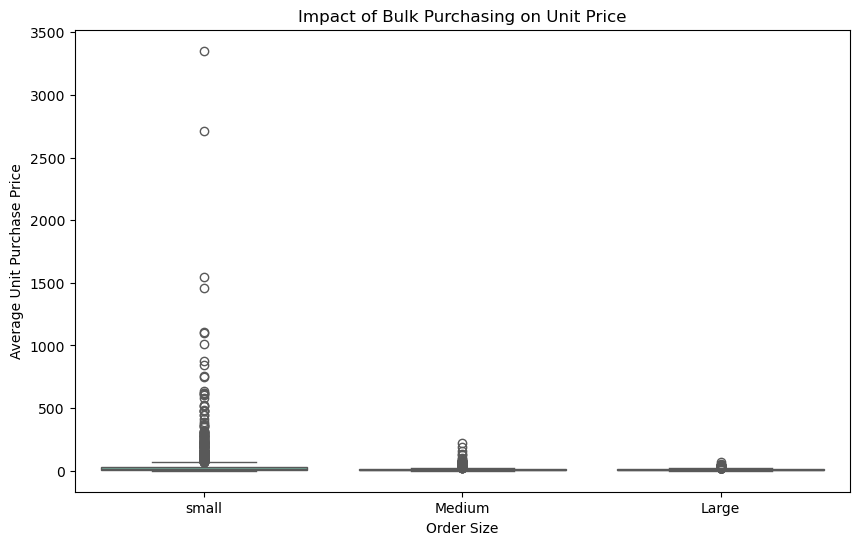

In [124]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

In [129]:
df[df['StockTurnover'] < 1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover',ascending = True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.500000
WEIN BAUER INC,0.666667
Dunn Wine Brokers,0.666667
THE IMPORTED GRAPE LLC,0.675282
JEWELL TOWNE VINEYARDS,0.686029
TY KU LLC,0.692131
AMERICAN SPIRITS EXCHANGE,0.697917
SURVILLE ENTERPRISES CORP,0.698441
"PREMIUM PORT WINES, INC.",0.700630


In [130]:
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]
print('Total Unsold Capital:', format_dollars(df["UnsoldInventoryValue"].sum()))

Total Unsold Capital: 37.50M


In [132]:
inventory_value_per_vendor = df.groupby(
    "VendorName"
)["UnsoldInventoryValue"].sum().reset_index()

inventory_value_per_vendor = inventory_value_per_vendor.sort_values(
    by="UnsoldInventoryValue",
    ascending=False
)

inventory_value_per_vendor["UnsoldInventoryValue"] = (
    inventory_value_per_vendor["UnsoldInventoryValue"]
    .apply(format_dollars)
)

inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
23,DIAGEO NORTH AMERICA INC,4.34M
50,MARTIGNETTI COMPANIES,3.82M
18,CONSTELLATION BRANDS INC,3.26M
27,E & J GALLO WINERY,2.37M
61,PERNOD RICARD USA,2.35M
40,JIM BEAM BRANDS COMPANY,2.19M
5,BACARDI USA INC,2.05M
47,M S WALKER INC,1.56M
102,WINE GROUP INC,1.23M
66,PROXIMO SPIRITS INC.,1.20M


In [133]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

In [134]:
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

In [135]:
top_vendors

0        1.810073
1        0.854665
2        1.507714
3        7.650145
4        5.135872
          ...    
3217    92.394030
3280    89.770746
3281    89.883453
3351    94.839635
3439    93.840088
Name: ProfitMargin, Length: 1514, dtype: float64

In [136]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err

    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (15.66, 17.06), Mean: 16.36
Low Vendors 95% CI: (43.52, 46.28), Mean: 44.90


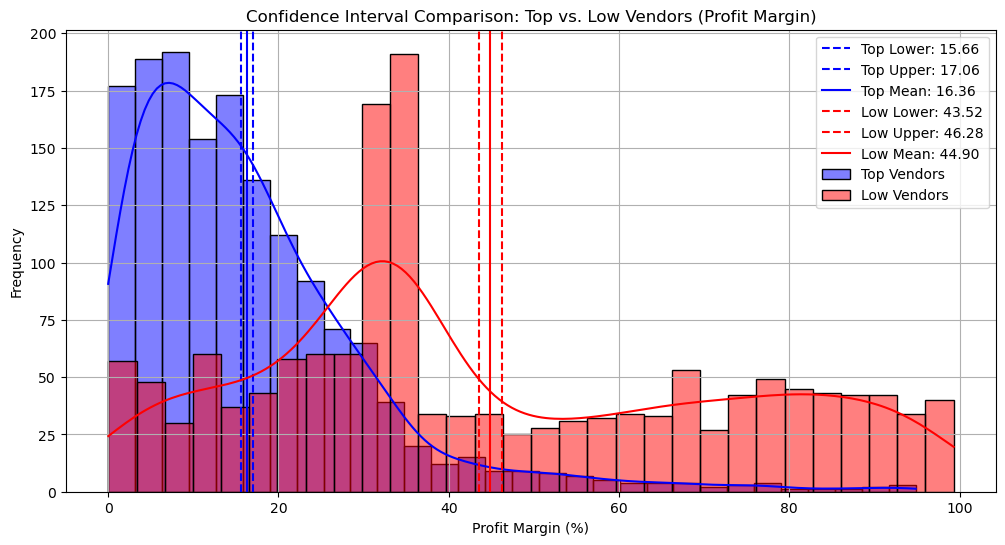

In [137]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(
    top_vendors,
    kde=True,
    color="blue",
    bins=30,
    alpha=0.5,
    label="Top Vendors"
)
plt.axvline(
    top_lower,
    color="blue",
    linestyle="--",
    label=f"Top Lower: {top_lower:.2f}"
)
plt.axvline(
    top_upper,
    color="blue",
    linestyle="--",
    label=f"Top Upper: {top_upper:.2f}"
)
plt.axvline(
    top_mean,
    color="blue",
    linestyle="-",
    label=f"Top Mean: {top_mean:.2f}"
)

# Low Vendors Plot
sns.histplot(
    low_vendors,
    kde=True,
    color="red",
    bins=30,
    alpha=0.5,
    label="Low Vendors"
)
plt.axvline(
    low_lower,
    color="red",
    linestyle="--",
    label=f"Low Lower: {low_lower:.2f}"
)
plt.axvline(
    low_upper,
    color="red",
    linestyle="--",
    label=f"Low Upper: {low_upper:.2f}"
)
plt.axvline(
    low_mean,
    color="red",
    linestyle="-",
    label=f"Low Mean: {low_mean:.2f}"
)

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

plt.show()

In [138]:

# Define top and low-performing vendors based on sales quartiles
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Perform Two-Sample T-Test (Welch's t-test)
t_stat, p_value = ttest_ind(
    top_vendors,
    low_vendors,
    equal_var=False
)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")

if p_value < 0.05:
    print(
        "Reject H₀: There is a significant difference in profit margins "
        "between top and low-performing vendors."
    )
else:
    print(
        "Fail to Reject H₀: No significant difference in profit margins."
    )

T-Statistic: -36.1873, P-Value: 0.0000
Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.
